<a href="https://colab.research.google.com/github/Erik435/Analisis_Datos/blob/Erikf/Analisis_Social_Media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
!kaggle datasets download algozee/teenager-menthal-healy

Dataset URL: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy
License(s): apache-2.0
100% 15.8k/15.8k [00:00<00:00, 24.3MB/s]



In [4]:
!unzip /content/teenager-menthal-healy.zip


Archive:  /content/teenager-menthal-healy.zip
  inflating: Teen_Mental_Health_Dataset.csv  


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [6]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [9]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [10]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [14]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [15]:
df['gender'].unique()

array(['male', 'female'], dtype=object)

In [17]:
df['platform_usage'].unique()

array(['Instagram', 'TikTok', 'Both'], dtype=object)

In [18]:
df['social_interaction_level'].unique()

array(['low', 'high', 'medium'], dtype=object)

In [19]:
df['depression_label'].unique()

array([0, 1])

In [20]:
df.columns = df.columns.str.strip()

In [22]:
df.groupby('depression_label').size()

,0
depression_label,
0,1169
1,31


In [23]:
df.groupby('platform_usage').size()

,0
platform_usage,
Both,391
Instagram,411
TikTok,398


In [24]:
df = df.dropna()

In [25]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [26]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [27]:
df.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [32]:
df.columns = df.columns.str.strip()

In [33]:
for col in df.columns:
    print(f"'{col}'")

'age'
'daily_social_media_hours'
'sleep_hours'
'screen_time_before_sleep'
'academic_performance'
'physical_activity'
'stress_level'
'anxiety_level'
'addiction_level'
'depression_label'
'gender_female'
'gender_male'
'platform_usage_Both'
'platform_usage_Instagram'
'platform_usage_TikTok'
'social_interaction_level_high'
'social_interaction_level_low'
'social_interaction_level_medium'


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1200 non-null   int64  
 1   daily_social_media_hours         1200 non-null   float64
 2   sleep_hours                      1200 non-null   float64
 3   screen_time_before_sleep         1200 non-null   float64
 4   academic_performance             1200 non-null   float64
 5   physical_activity                1200 non-null   float64
 6   stress_level                     1200 non-null   int64  
 7   anxiety_level                    1200 non-null   int64  
 8   addiction_level                  1200 non-null   int64  
 9   depression_label                 1200 non-null   int64  
 10  gender_female                    1200 non-null   bool   
 11  gender_male                      1200 non-null   bool   
 12  platform_usage_Both 

In [37]:
df = df.drop([
    'gender_female',
    'platform_usage_Both',
    'social_interaction_level_low'
], axis=1)

In [39]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']

In [40]:
y = df['depression_label']
print(y.value_counts())

depression_label
0    1169
1      31
Name: count, dtype: int64


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
import random

indices = random.sample(range(len(df)), 500)

In [45]:
df = df.sample(frac=1, random_state=42)

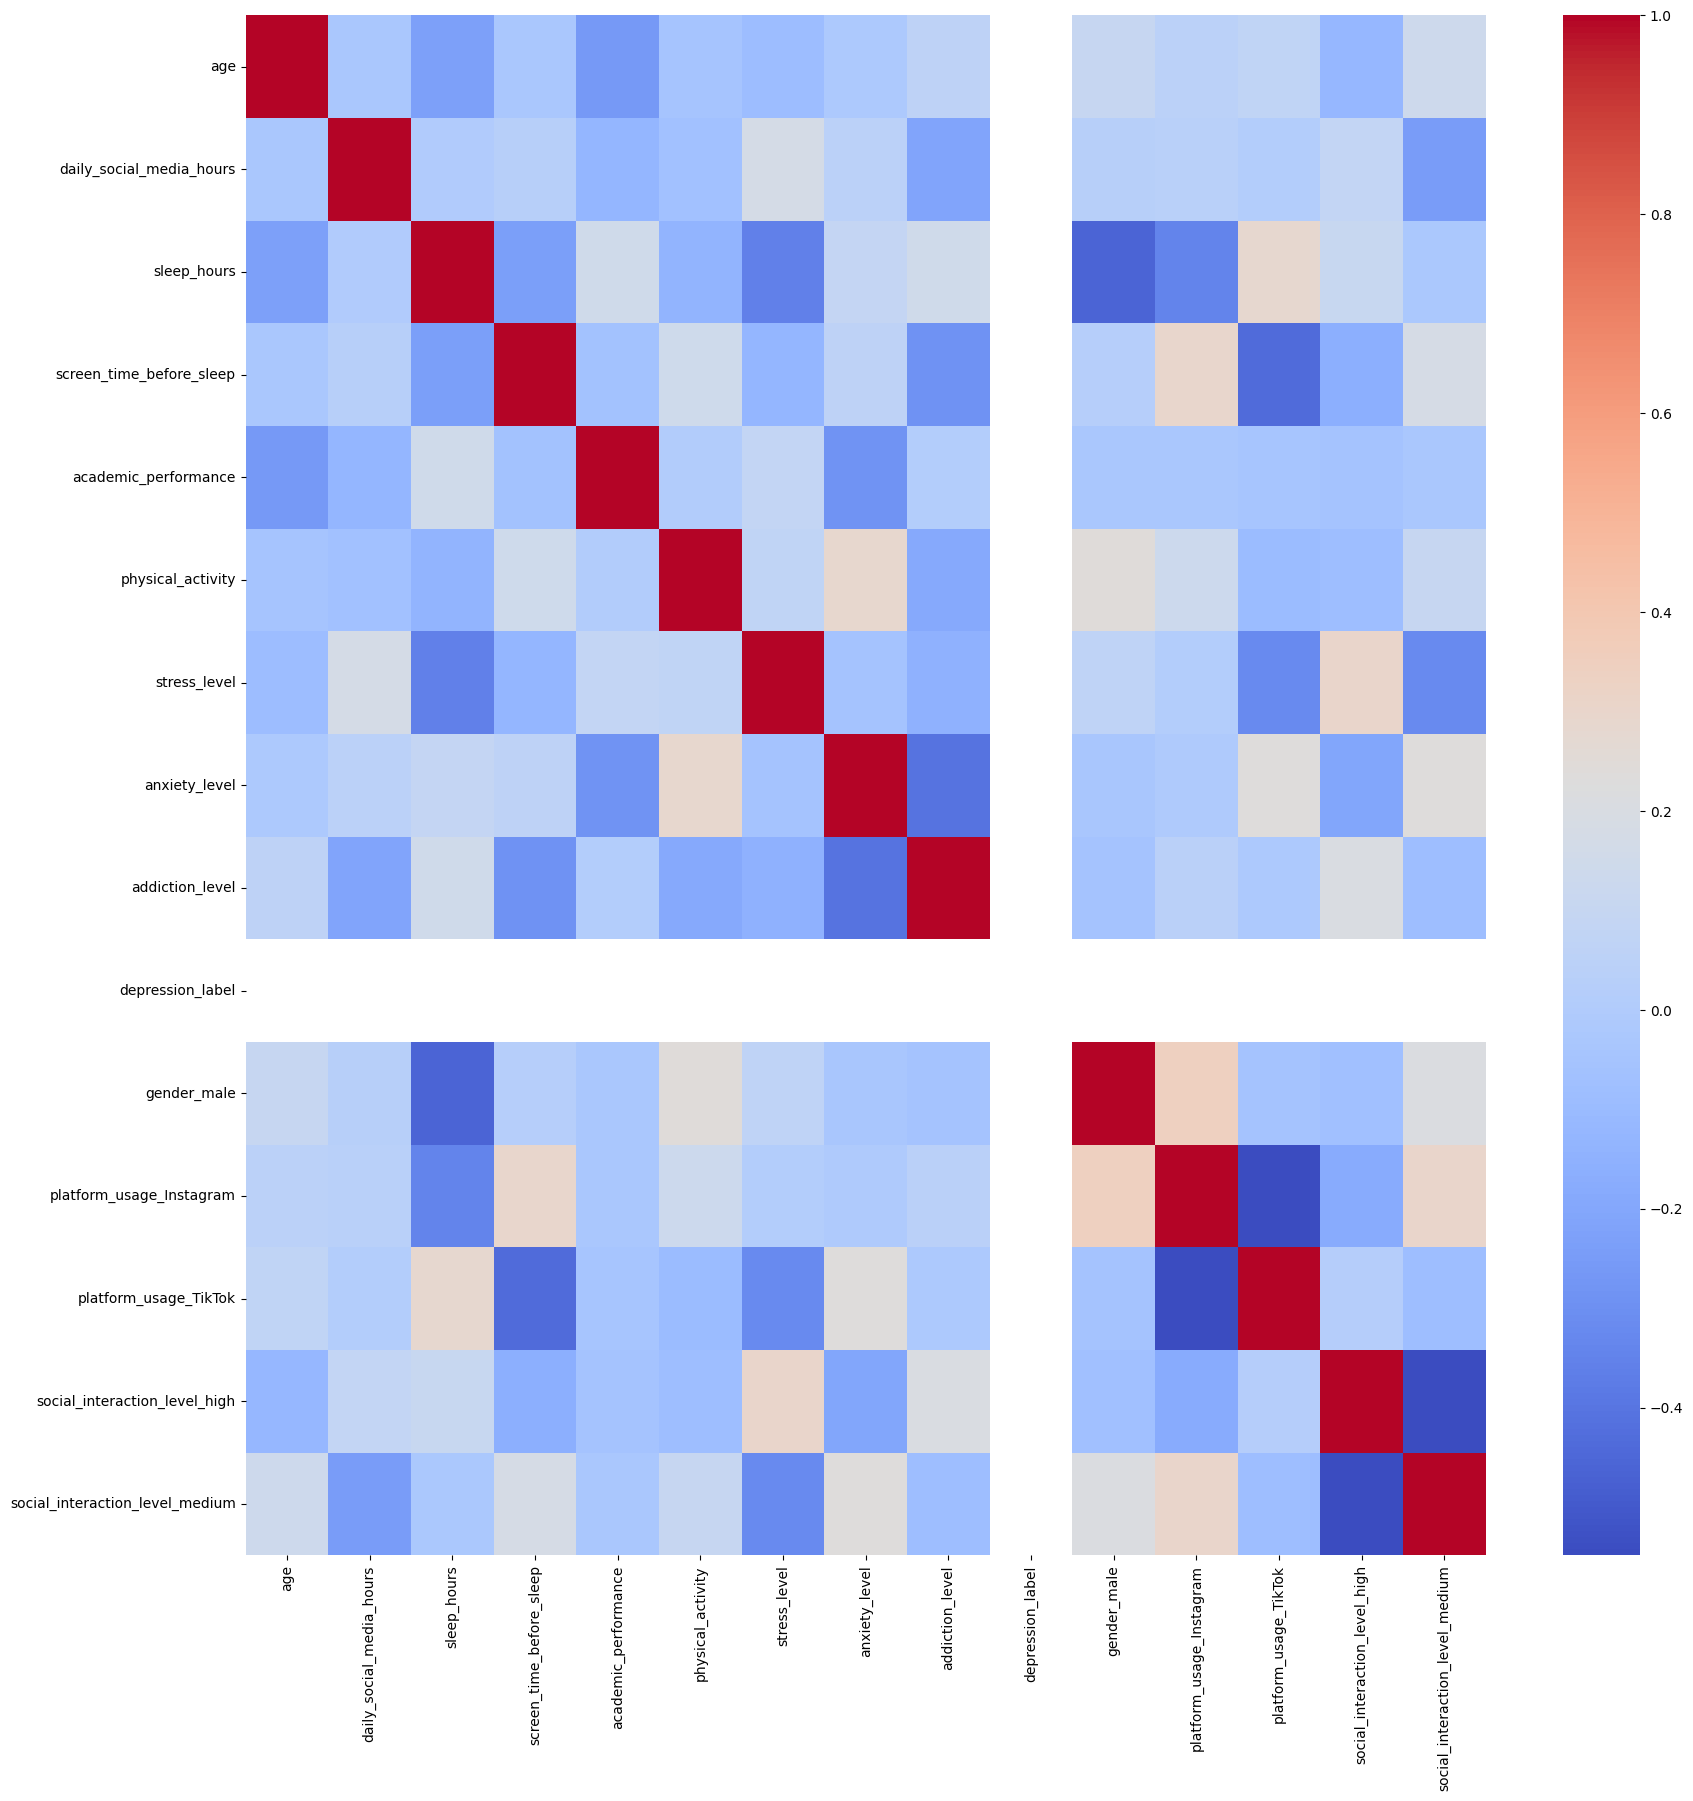

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,20))
sns.heatmap(df[df['depression_label'] == 1].corr(), cmap='coolwarm')
plt.show()

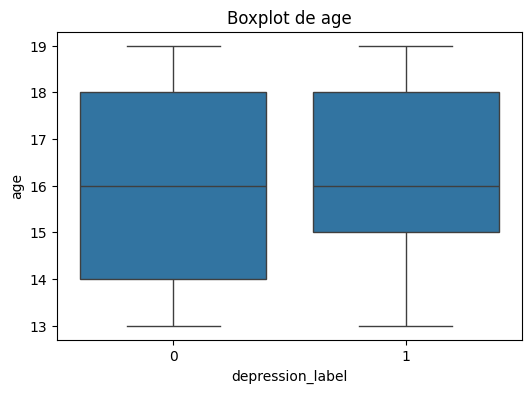

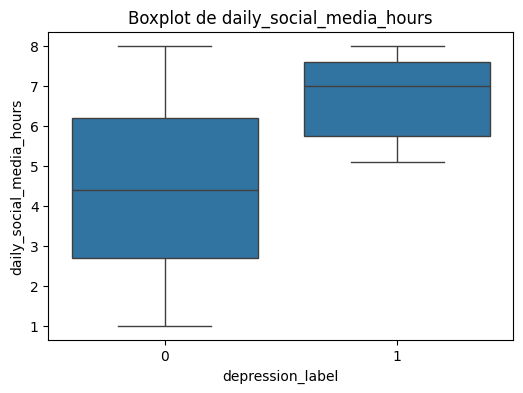

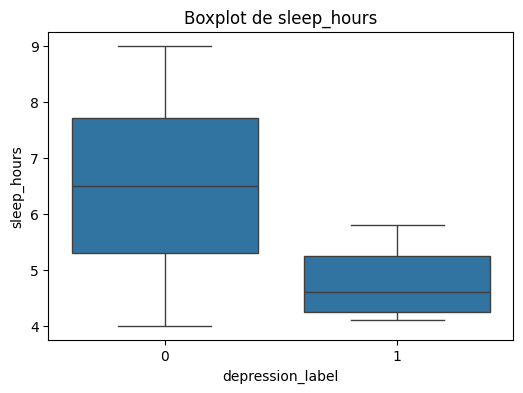

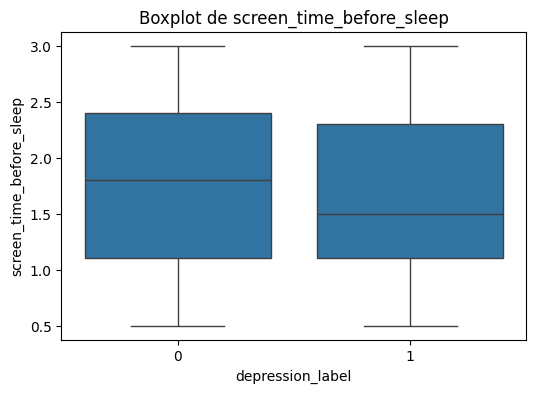

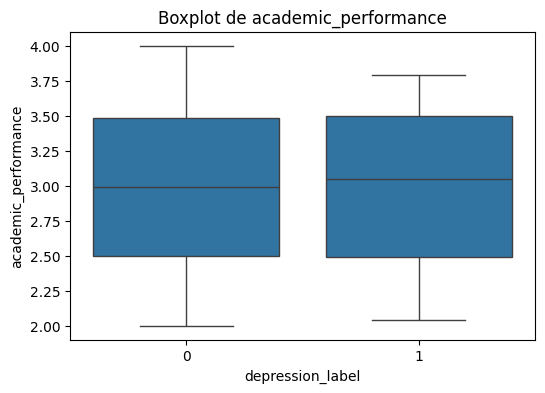

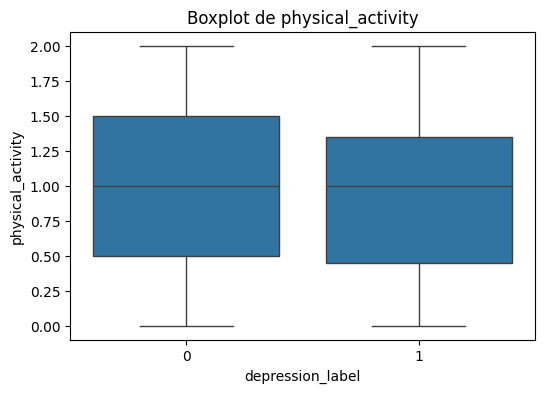

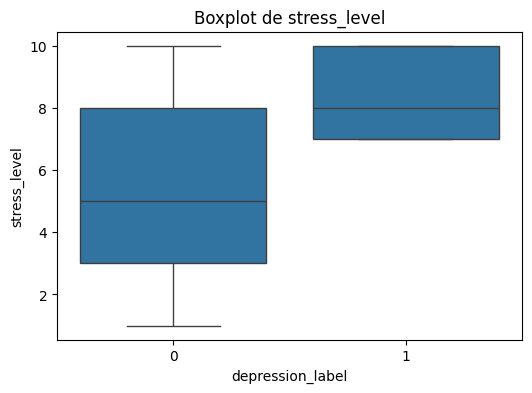

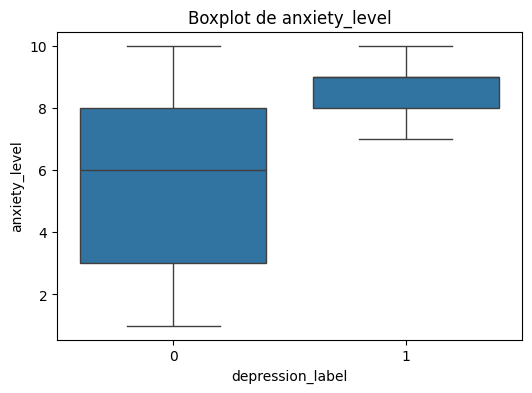

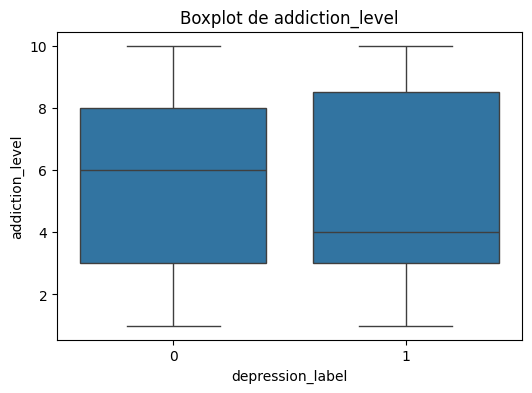

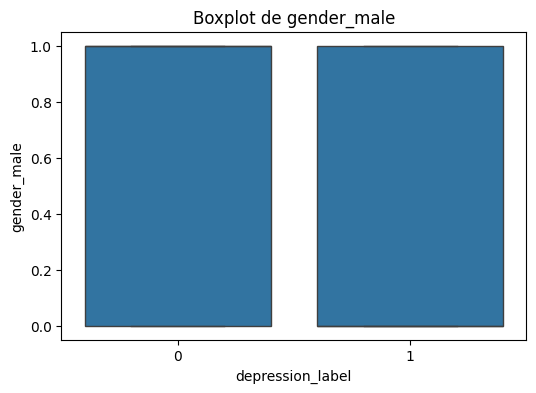

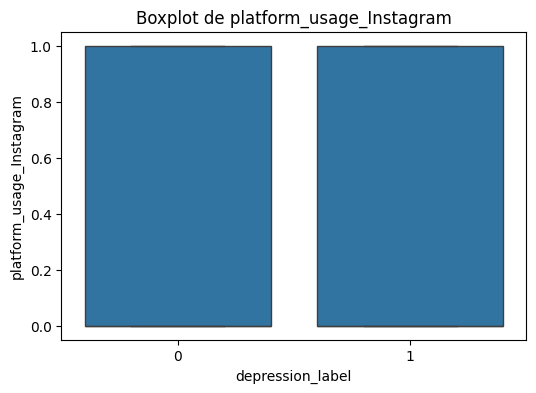

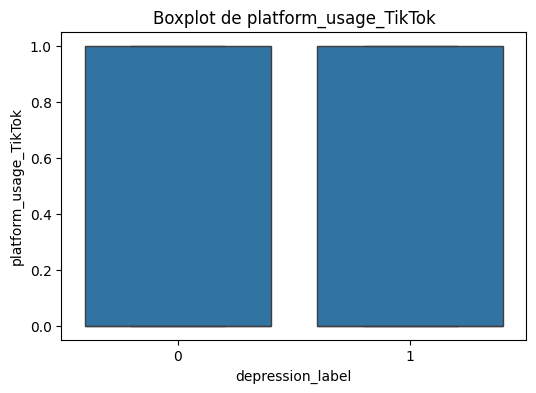

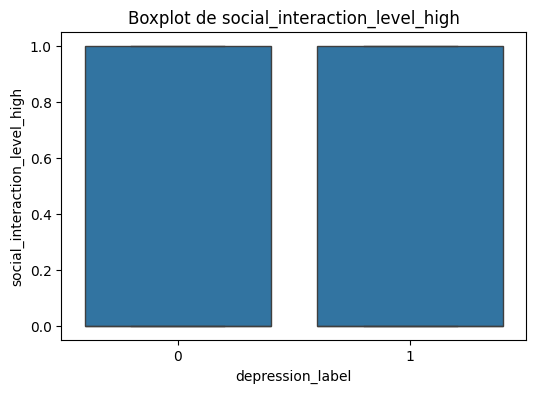

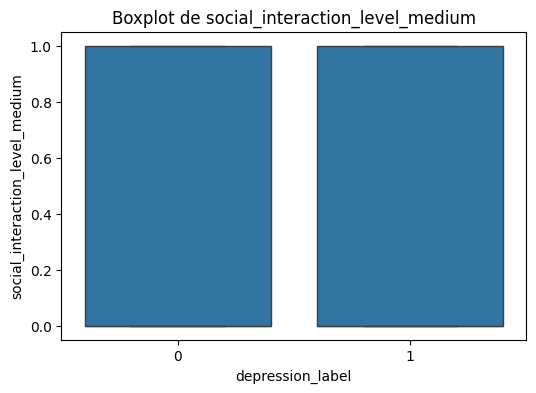

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
    if col != 'depression_label':
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df, x='depression_label', y=col)
        plt.title(f"Boxplot de {col}")
        plt.show()

In [50]:
df.groupby('depression_label').size()

,0
depression_label,
0,1169
1,31


In [51]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [52]:
df.shape

(1200, 15)

In [53]:
X = df.drop('depression_label', axis=1)
y = df['depression_label'].values

In [54]:
X.shape, y.shape, X.max(), X.min()

((1200, 14),
 (1200,),
 age                                  19
 daily_social_media_hours            8.0
 sleep_hours                         9.0
 screen_time_before_sleep            3.0
 academic_performance                4.0
 physical_activity                   2.0
 stress_level                         10
 anxiety_level                        10
 addiction_level                      10
 gender_male                        True
 platform_usage_Instagram           True
 platform_usage_TikTok              True
 social_interaction_level_high      True
 social_interaction_level_medium    True
 dtype: object,
 age                                   13
 daily_social_media_hours             1.0
 sleep_hours                          4.0
 screen_time_before_sleep             0.5
 academic_performance                 2.0
 physical_activity                    0.0
 stress_level                           1
 anxiety_level                          1
 addiction_level                        1
 gender_m

In [55]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [58]:
y_pred = model.predict(X_test)

In [59]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.975


Matriz de Confusión:
[[234   0]
 [  6   0]]


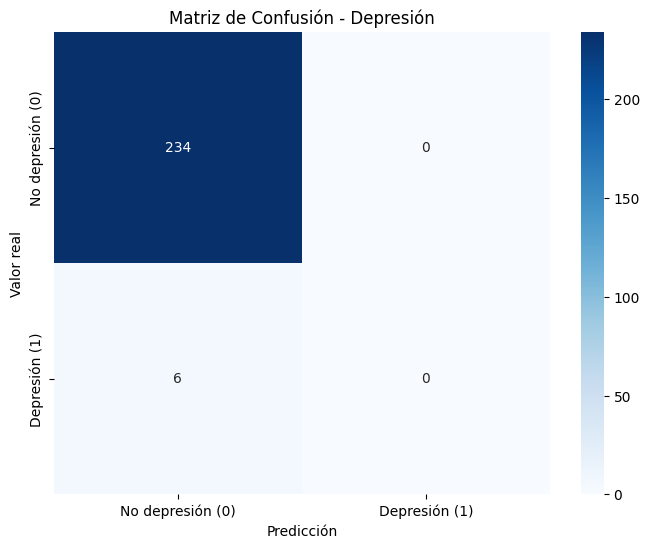

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Depresión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

# Etiquetas de clases
plt.xticks([0.5, 1.5], ['No depresión (0)', 'Depresión (1)'])
plt.yticks([0.5, 1.5], ['No depresión (0)', 'Depresión (1)'])

plt.show()

In [67]:
features_df = pd.DataFrame({
    'feature': df.drop('depression_label', axis=1).columns,
    'importance': feature_importances
})

In [68]:
features_df.sort_values('importance', ascending=False).head(10)

,feature,importance
2,sleep_hours,0.213614
1,daily_social_media_hours,0.182253
7,anxiety_level,0.123526
6,stress_level,0.121114
4,academic_performance,0.072565
3,screen_time_before_sleep,0.069789
8,addiction_level,0.065018
5,physical_activity,0.053129
0,age,0.035741
11,platform_usage_TikTok,0.014830


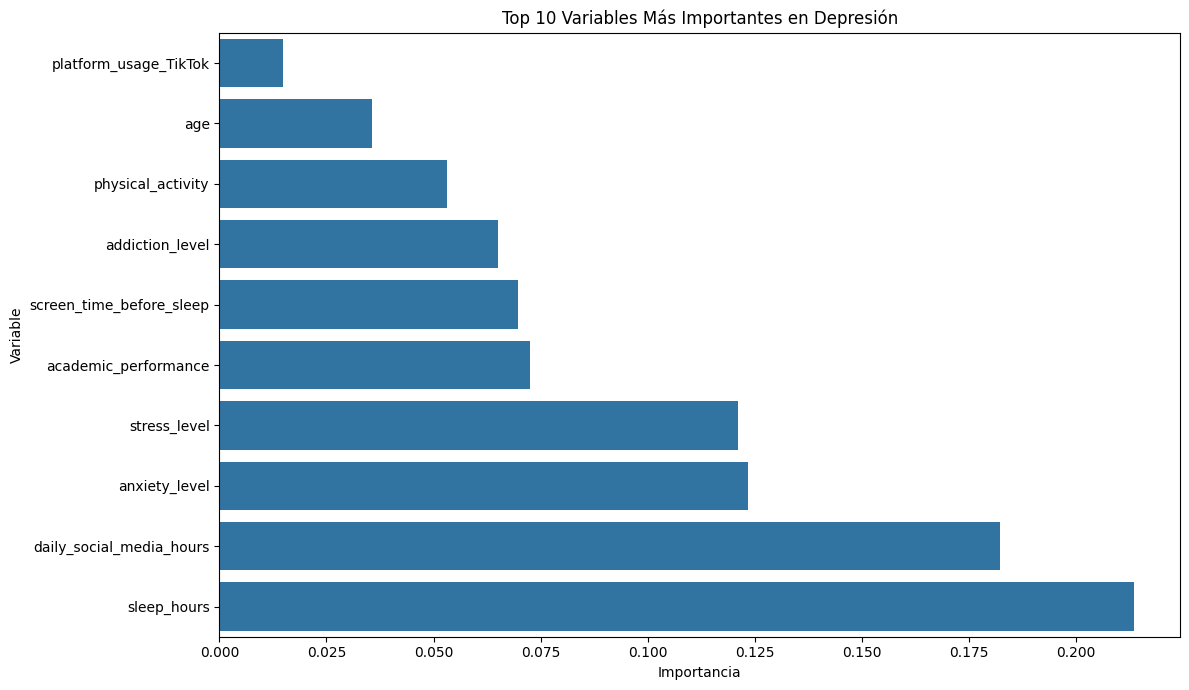

In [69]:
top_features = features_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='importance',
    y='feature',
    data=top_features.sort_values(by='importance')  # opcional: mejor visual
)

plt.title('Top 10 Variables Más Importantes en Depresión')
plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [71]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [76]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [77]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [79]:
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [80]:
model = SimpleNN(X_train.shape[1], hidden_dim=128, output_dim=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch 1/10, Loss: 0.3824
Epoch 2/10, Loss: 0.2004
Epoch 3/10, Loss: 0.1412
Epoch 4/10, Loss: 0.1184
Epoch 5/10, Loss: 0.1061
Epoch 6/10, Loss: 0.0972
Epoch 7/10, Loss: 0.0901
Epoch 8/10, Loss: 0.0835
Epoch 9/10, Loss: 0.0779
Epoch 10/10, Loss: 0.0728


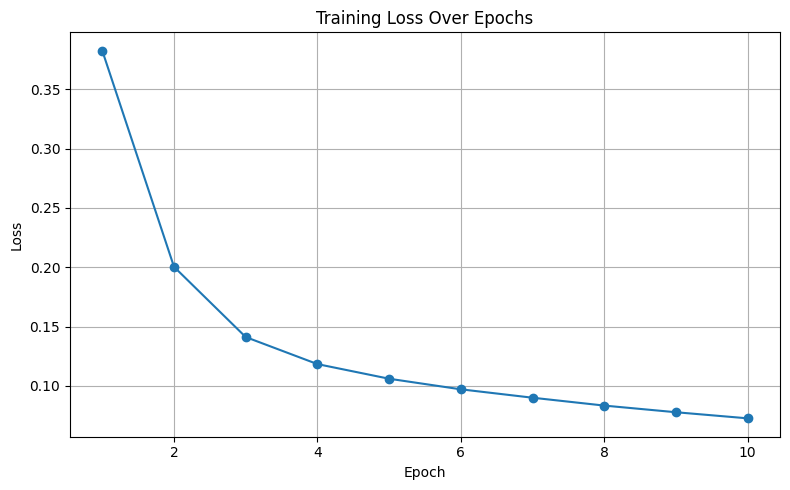

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [81]:

# Training loop with loss tracking
epochs = 10
losses = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Plot the loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.tolist())
        y_pred.extend(predicted.tolist())

print(classification_report(y_true, y_pred))